# Decision Tree Pruning and Complexity Analysis

In this notebook, we'll explore how decision trees handle complexity through pre-pruning and post-pruning techniques, and examine the bias-variance tradeoff related to tree depth.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


## Understanding Tree Complexity and Overfitting

Decision trees can grow very deep and capture noise in the training data, leading to overfitting. Let's examine how tree depth affects model performance.

In [2]:
# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=8, 
                          n_redundant=2, n_clusters_per_class=1, random_state=42)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 800
Test set size: 200
Number of features: 10


## Bias-Variance Tradeoff with Tree Depth

As we increase the depth of a decision tree, the model becomes more complex, reducing bias but potentially increasing variance. Let's visualize this tradeoff.

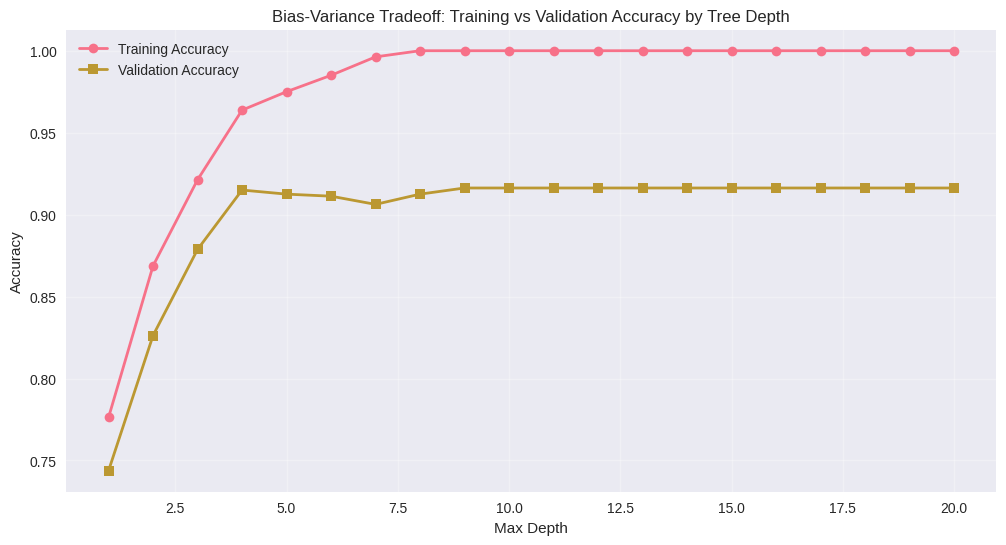

Optimal depth based on validation score: 9
Best validation score: 0.9163


In [3]:
# Analyze the effect of tree depth on bias-variance tradeoff
max_depths = range(1, 21)
train_scores = []
val_scores = []

for depth in max_depths:
    # Create and train the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Calculate scores
    train_score = dt.score(X_train, y_train)
    val_score = cross_val_score(dt, X_train, y_train, cv=5).mean()
    
    train_scores.append(train_score)
    val_scores.append(val_score)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(max_depths, train_scores, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(max_depths, val_scores, label='Validation Accuracy', marker='s', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Training vs Validation Accuracy by Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find optimal depth
optimal_depth = max_depths[np.argmax(val_scores)]
print(f"Optimal depth based on validation score: {optimal_depth}")
print(f"Best validation score: {max(val_scores):.4f}")

## Pre-Pruning Techniques

Pre-pruning involves stopping the tree growth early using hyperparameters. Common pre-pruning techniques include:
- **max_depth**: Maximum depth of the tree
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples required at a leaf node
- **max_features**: Number of features to consider for best split
- **min_impurity_decrease**: Minimum impurity decrease required for split

In [4]:
# Compare different pre-pruning strategies
pruning_strategies = {
    'No Pruning': {},
    'Max Depth = 5': {'max_depth': 5},
    'Min Samples Split = 10': {'min_samples_split': 10},
    'Min Samples Leaf = 5': {'min_samples_leaf': 5},
    'Max Features = sqrt': {'max_features': 'sqrt'},
    'Combined Pruning': {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5}
}

# Evaluate each strategy
results = []
for name, params in pruning_strategies.items():
    dt = DecisionTreeClassifier(random_state=42, **params)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    cv_score = cross_val_score(dt, X_train, y_train, cv=5).mean()
    
    results.append({
        'Strategy': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'CV Score': cv_score,
        'Overfitting Gap': train_acc - test_acc
    })

# Display results
results_df = pd.DataFrame(results)
print("Pre-Pruning Strategy Comparison:")
print(results_df.round(4))

Pre-Pruning Strategy Comparison:
                 Strategy  Train Accuracy  Test Accuracy  CV Score  \
0              No Pruning          1.0000          0.950    0.9162   
1           Max Depth = 5          0.9750          0.940    0.9125   
2  Min Samples Split = 10          0.9900          0.940    0.9087   
3    Min Samples Leaf = 5          0.9712          0.945    0.9138   
4     Max Features = sqrt          1.0000          0.910    0.8962   
5        Combined Pruning          0.9650          0.945    0.9175   

   Overfitting Gap  
0           0.0500  
1           0.0350  
2           0.0500  
3           0.0262  
4           0.0900  
5           0.0200  


## Post-Pruning (Cost Complexity Pruning)

Post-pruning involves growing the tree fully and then removing branches. Scikit-learn implements cost complexity pruning using the `ccp_alpha` parameter.

In [5]:
# Cost complexity pruning demonstration
from sklearn.tree import DecisionTreeClassifier

# First, grow a large tree
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

# Get the path of effective alphas
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the largest alpha (which corresponds to the whole tree)
ccp_alphas = ccp_alphas[:-1]

# Train trees for different alpha values
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

print(f"Number of alphas tested: {len(ccp_alphas)}")
print(f"Alpha range: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]")

Number of alphas tested: 31
Alpha range: [0.000000, 0.079683]


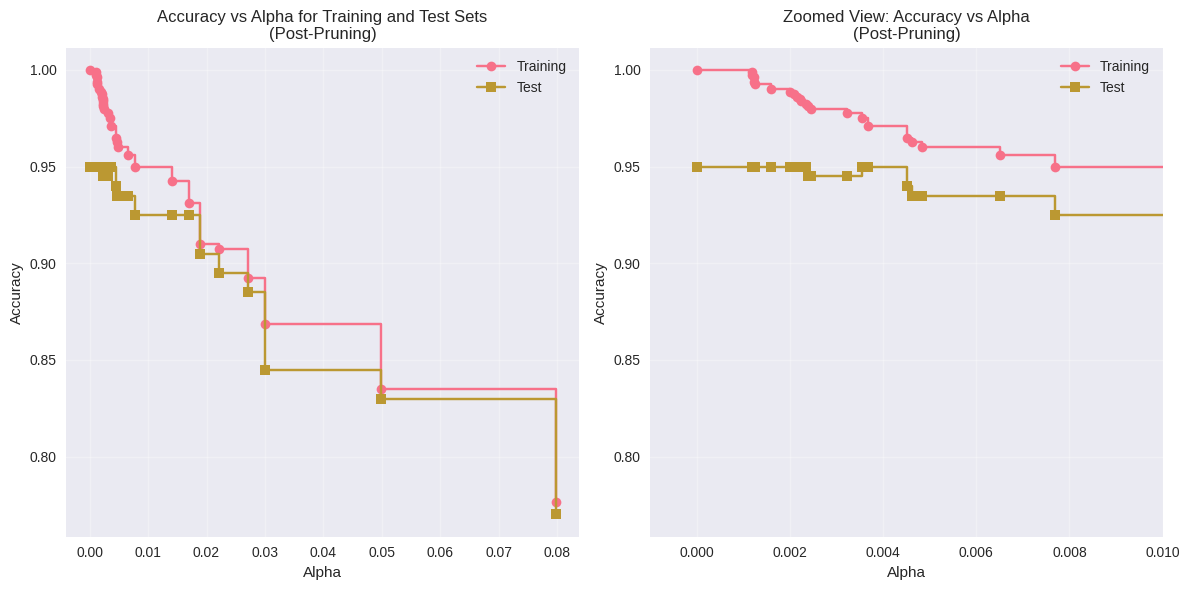

In [6]:
# Evaluate post-pruning effectiveness
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(ccp_alphas, train_scores, marker='o', label="Training", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='s', label="Test", drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha for Training and Test Sets\n(Post-Pruning)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(ccp_alphas, train_scores, marker='o', label="Training", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='s', label="Test", drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.xlim(-0.001, 0.01)  # Focus on small alpha values
plt.title("Zoomed View: Accuracy vs Alpha\n(Post-Pruning)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparing Pruned vs Unpruned Trees

Let's compare the performance of pruned vs unpruned trees and visualize their structures.

In [7]:
# Find the best alpha value
best_alpha_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Best alpha value: {best_alpha:.6f}")
print(f"Best test accuracy: {test_scores[best_alpha_idx]:.4f}")

# Train models
unpruned_model = DecisionTreeClassifier(random_state=42)
pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)

unpruned_model.fit(X_train, y_train)
pruned_model.fit(X_train, y_train)

# Compare metrics
models = {'Unpruned': unpruned_model, 'Pruned': pruned_model}
comparison_data = []

for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    n_nodes = model.tree_.node_count
    depth = model.tree_.max_depth
    
    comparison_data.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Nodes': n_nodes,
        'Depth': depth,
        'Overfitting Gap': train_acc - test_acc
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.round(4))

Best alpha value: 0.000000
Best test accuracy: 0.9500



Model Comparison:


      Model  Train Accuracy  Test Accuracy  Nodes  Depth  Overfitting Gap
0  Unpruned             1.0           0.95     87      8             0.05
1    Pruned             1.0           0.95     87      8             0.05


## Visualization: Tree Structure Comparison

Now let's visualize the difference between pruned and unpruned trees.

In [ ]:
# Visualize both trees (smaller versions to keep the notebook readable)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Create a limited depth tree for visualization purposes
viz_unpruned = DecisionTreeClassifier(max_depth=3, random_state=42)
viz_unpruned.fit(X_train, y_train)

viz_pruned = DecisionTreeClassifier(max_depth=3, ccp_alpha=0.001, random_state=42)
viz_pruned.fit(X_train, y_train)

plot_tree(viz_unpruned, ax=axes[0], filled=True, feature_names=[f'Feature_{i}' for i in range(X_train.shape[1])])
axes[0].set_title('Unpruned Tree (Limited to Depth 3 for Visualization)')

plot_tree(viz_pruned, ax=axes[1], filled=True, feature_names=[f'Feature_{i}' for i in range(X_train.shape[1])])
axes[1].set_title('Pruned Tree (Limited to Depth 3 for Visualization)')

plt.tight_layout()
plt.show()

## Real-world Dataset Example: Breast Cancer Dataset

Let's apply our understanding to a real-world dataset.

In [ ]:
# Load the breast cancer dataset
cancer_data = load_breast_cancer()
X_cancer, y_cancer = cancer_data.data, cancer_data.target

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X_cancer.shape}")
print(f"Classes: {cancer_data.target_names}")
print(f"Features: {list(cancer_data.feature_names[:5])}...")  # Show first 5 features

In [ ]:
# Apply pruning to the breast cancer dataset
def evaluate_pruning_on_dataset(X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n--- Results for {dataset_name} ---")
    
    # Find best alpha using cross-validation
    path = DecisionTreeClassifier().cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas[:-1]  # Exclude the last alpha (full tree)
    
    best_test_score = 0
    best_alpha = 0
    
    for alpha in ccp_alphas[::10]:  # Test every 10th alpha for efficiency
        dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
        dt.fit(X_train, y_train)
        
        test_score = dt.score(X_test, y_test)
        if test_score > best_test_score:
            best_test_score = test_score
            best_alpha = alpha
    
    # Train models with best alpha
    unpruned = DecisionTreeClassifier(random_state=42)
    pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
    
    unpruned.fit(X_train, y_train)
    pruned.fit(X_train, y_train)
    
    # Print results
    print(f"Best alpha: {best_alpha:.6f}")
    print(f"Unpruned - Train Acc: {unpruned.score(X_train, y_train):.4f}, Test Acc: {unpruned.score(X_test, y_test):.4f}")
    print(f"Pruned - Train Acc: {pruned.score(X_train, y_train):.4f}, Test Acc: {pruned.score(X_test, y_test):.4f}")
    print(f"Unpruned tree depth: {unpruned.tree_.max_depth}, nodes: {unpruned.tree_.node_count}")
    print(f"Pruned tree depth: {pruned.tree_.max_depth}, nodes: {pruned.tree_.node_count}")
    
    return unpruned, pruned

# Evaluate on breast cancer dataset
unpruned_cancer, pruned_cancer = evaluate_pruning_on_dataset(
    X_train_c, X_test_c, y_train_c, y_test_c, "Breast Cancer Dataset"
)

## Key Takeaways

1. **Pre-pruning** controls tree growth during training using parameters like max_depth, min_samples_split, etc.
2. **Post-pruning** allows full tree growth then removes branches based on cost complexity.
3. The **bias-variance tradeoff** shows that deeper trees have lower bias but higher variance.
4. Proper pruning helps balance model complexity and generalization.
5. Cross-validation is essential for selecting optimal hyperparameters.

Both techniques are valuable tools for preventing overfitting and achieving better generalization in decision trees.